<a href="https://colab.research.google.com/github/nexageapps/AI/blob/main/Basic/B05b%20-%20Training%20and%20Optimization%20(COMPSCI%20714).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B05b: Training and Optimization - COMPSCI 714 Lecture 3

**Course Alignment:** COMPSCI 714 - AI Architecture and Design (Lecture 3)  
**Practical Game** - https://nexageapps.github.io/AI/gradient-descent/

---

## ⚠️ Important Disclaimer

This notebook is an **independent educational resource** created to help students understand training and optimization concepts. This is **NOT official University of Auckland course material** and is not affiliated with or endorsed by the university.

**Use Responsibly:**
- This is a learning companion, not a substitute for lectures
- Understand concepts first, then implement independently for assignments
- Follow the University of Auckland's Academic Integrity Policy
- Use for learning and understanding, not for copying solutions

---

## Learning Objectives

This notebook covers COMPSCI 714 Lecture 3 topics:

1. **Learning as Optimization** — minimizing loss/cost functions
2. **Gradient Descent Algorithm** — w ← w - α∇L(w)
3. **Learning Rate Selection** — balancing speed and stability
4. **Batch Gradient Descent** — full dataset, smooth but slow
5. **Stochastic Gradient Descent (SGD)** — 1 sample, efficient but noisy
6. **Mini-batch Gradient Descent** — best of both worlds
7. **Backpropagation** — efficient gradient computation
8. **Worked Backpropagation Example** — Matt Mazur's step-by-step
9. **Automatic Differentiation** — TensorFlow, PyTorch

## Prerequisites

- B01a - Arithmetic (tensor operations)
- B02 - Linear Regression (gradient descent basics)
- B05 - Neural Network Fundamentals
- B05a - Neural Networks Theory (Lecture 2)
- Basic calculus (derivatives, chain rule)

---

In [5]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import time

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Set random seed
np.random.seed(42)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
NumPy version: 1.26.4


---

# Part 1: Learning as Optimization

## 1.1 The Optimization Problem

Machine learning is fundamentally an **optimization problem**:

**Goal:** Find parameters θ that minimize a loss function L(θ)

```
θ* = argmin L(θ)
      θ
```

Where:
- **θ**: Model parameters (weights w, biases b)
- **L(θ)**: Loss/cost function measuring prediction error
- **θ***: Optimal parameters that minimize loss

### Common Loss Functions

**Mean Squared Error (Regression):**
```
L(θ) = (1/N) Σᵢ (yᵢ - ŷᵢ)²
```

**Binary Cross-Entropy (Binary Classification):**
```
L(θ) = -(1/N) Σᵢ [yᵢ log(ŷᵢ) + (1-yᵢ) log(1-ŷᵢ)]
```

**Categorical Cross-Entropy (Multi-class):**
```
L(θ) = -(1/N) Σᵢ Σⱼ yᵢⱼ log(ŷᵢⱼ)
```

In [6]:
# Implement common loss functions

def mse_loss(y_true, y_pred):
    """Mean Squared Error"""
    return np.mean((y_true - y_pred) ** 2)

def binary_cross_entropy(y_true, y_pred):
    """Binary Cross-Entropy Loss"""
    epsilon = 1e-15  # Prevent log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def categorical_cross_entropy(y_true, y_pred):
    """Categorical Cross-Entropy Loss"""
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# Test loss functions
print("Loss Function Examples:")
print("="*60)

# MSE example
y_true_reg = np.array([1.0, 2.0, 3.0, 4.0])
y_pred_reg = np.array([1.1, 2.2, 2.8, 4.3])
print(f"\nMSE Loss: {mse_loss(y_true_reg, y_pred_reg):.4f}")

# Binary cross-entropy example
y_true_bin = np.array([1, 0, 1, 1, 0])
y_pred_bin = np.array([0.9, 0.1, 0.8, 0.7, 0.2])
print(f"Binary Cross-Entropy: {binary_cross_entropy(y_true_bin, y_pred_bin):.4f}")

# Categorical cross-entropy example
y_true_cat = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_cat = np.array([[0.8, 0.1, 0.1], [0.2, 0.7, 0.1], [0.1, 0.2, 0.7]])
print(f"Categorical Cross-Entropy: {categorical_cross_entropy(y_true_cat, y_pred_cat):.4f}")
print("="*60)

Loss Function Examples:

MSE Loss: 0.0450
Binary Cross-Entropy: 0.2027
Categorical Cross-Entropy: 0.3122


## 1.2 Visualizing the Loss Surface

Let's visualize a simple 2D loss surface to understand the optimization landscape.

---

## Exercises

Test your understanding with these hands-on exercises. Try to solve them before looking at the hints.


### Exercise 1: Learning Rate Finder

Implement a simple learning rate finder: train a model on MNIST while exponentially increasing the learning rate from 1e-6 to 1.0 over one epoch. Plot loss vs learning rate and identify the optimal range.



Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



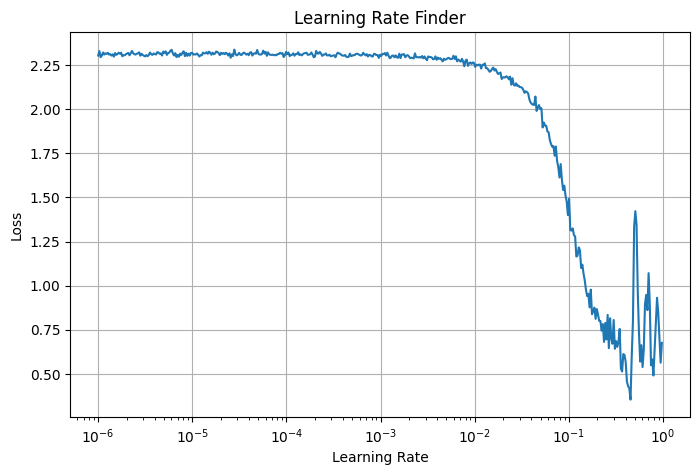

In [2]:
# Start with lr = 1e-6, multiply by 1.1 each batch
# Record the loss at each step
# Plot loss vs lr (log scale on x-axis)
# The optimal lr is just before the loss starts increasing sharply

# Your code here
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# MNIST Dataset
# ----------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

# ----------------------------
# Simple Neural Network
# ----------------------------
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleNet()

criterion = nn.CrossEntropyLoss()

# ----------------------------
# Learning Rate Finder
# ----------------------------
start_lr = 1e-6
end_lr = 1.0

optimizer = optim.SGD(model.parameters(), lr=start_lr)

num_batches = len(train_loader)

# Exponential LR multiplier
lr_mult = (end_lr / start_lr) ** (1 / num_batches)

lrs = []
losses = []

model.train()

for images, labels in train_loader:

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    current_lr = optimizer.param_groups[0]['lr']

    lrs.append(current_lr)
    losses.append(loss.item())

    # Increase LR exponentially
    optimizer.param_groups[0]['lr'] *= lr_mult

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8,5))
plt.plot(lrs, losses)
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate Finder")
plt.grid(True)
plt.show()

### Exercise 2: Optimizer Comparison

Train the same model architecture on MNIST using three different optimizers: SGD, SGD with Momentum (0.9), and Adam. Plot the training loss curves on the same graph and compare convergence speed.



SGD | Epoch 1/10 | Loss = 1.6953
SGD | Epoch 2/10 | Loss = 0.7804
SGD | Epoch 3/10 | Loss = 0.5407
SGD | Epoch 4/10 | Loss = 0.4534
SGD | Epoch 5/10 | Loss = 0.4083
SGD | Epoch 6/10 | Loss = 0.3801
SGD | Epoch 7/10 | Loss = 0.3606
SGD | Epoch 8/10 | Loss = 0.3458
SGD | Epoch 9/10 | Loss = 0.3337
SGD | Epoch 10/10 | Loss = 0.3239
Momentum | Epoch 1/10 | Loss = 0.6155
Momentum | Epoch 2/10 | Loss = 0.2942
Momentum | Epoch 3/10 | Loss = 0.2445
Momentum | Epoch 4/10 | Loss = 0.2081
Momentum | Epoch 5/10 | Loss = 0.1804
Momentum | Epoch 6/10 | Loss = 0.1597
Momentum | Epoch 7/10 | Loss = 0.1429
Momentum | Epoch 8/10 | Loss = 0.1287
Momentum | Epoch 9/10 | Loss = 0.1181
Momentum | Epoch 10/10 | Loss = 0.1081
Adam | Epoch 1/10 | Loss = 0.4127
Adam | Epoch 2/10 | Loss = 0.1895
Adam | Epoch 3/10 | Loss = 0.1391
Adam | Epoch 4/10 | Loss = 0.1081
Adam | Epoch 5/10 | Loss = 0.0869
Adam | Epoch 6/10 | Loss = 0.0721
Adam | Epoch 7/10 | Loss = 0.0600
Adam | Epoch 8/10 | Loss = 0.0503
Adam | Epoch 9/1

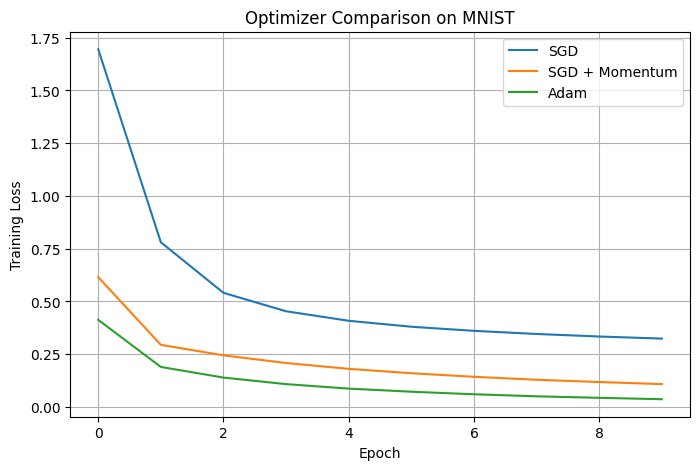

In [3]:
# optimizers = [
#     tf.keras.optimizers.SGD(learning_rate=0.01),
#     tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
#     tf.keras.optimizers.Adam(learning_rate=0.001),
# ]

# Train each and collect history.history['loss']
# Plot all three on the same graph
# Your code here

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ---------------------------------------
# Load MNIST
# ---------------------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

# ---------------------------------------
# Model Definition
# ---------------------------------------
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

# ---------------------------------------
# Training Function
# ---------------------------------------
def train_model(optimizer_name, epochs=10):

    model = SimpleNet()

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    elif optimizer_name == "Momentum":
        optimizer = optim.SGD(
            model.parameters(),
            lr=0.01,
            momentum=0.9
        )

    elif optimizer_name == "Adam":
        optimizer = optim.Adam(
            model.parameters(),
            lr=0.001
        )

    losses = []

    for epoch in range(epochs):

        running_loss = 0

        for images, labels in train_loader:

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        losses.append(epoch_loss)

        print(
            f"{optimizer_name} | Epoch {epoch+1}/{epochs} "
            f"| Loss = {epoch_loss:.4f}"
        )

    return losses

# ---------------------------------------
# Train with Different Optimizers
# ---------------------------------------
sgd_losses = train_model("SGD")

momentum_losses = train_model("Momentum")

adam_losses = train_model("Adam")

# ---------------------------------------
# Plot Comparison
# ---------------------------------------
plt.figure(figsize=(8,5))

plt.plot(sgd_losses, label="SGD")

plt.plot(momentum_losses, label="SGD + Momentum")

plt.plot(adam_losses, label="Adam")

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title("Optimizer Comparison on MNIST")

plt.legend()

plt.grid(True)

plt.show()


/var/folders/20/z8cs1fd56xg91ycftn6fzq640000gn/T/ipykernel_23036/66894766.py:45: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/20/z8cs1fd56xg91ycftn6fzq640000gn/T/ipykernel_23036/66894766.py:45: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/arjunkarthik/Applications/MAI/AI/AI/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/arjunkarthik/Applications/MAI/AI/AI/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


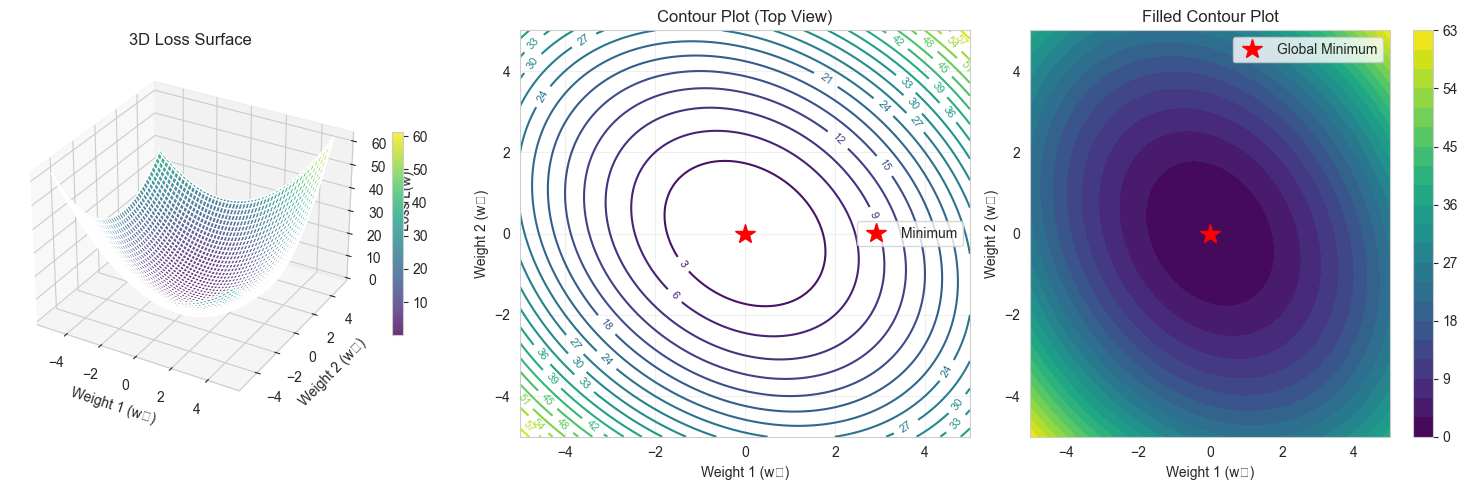


OPTIMIZATION LANDSCAPE
The loss surface shows:
  • Higher values (yellow) = worse predictions
  • Lower values (purple) = better predictions
  • Red star = optimal weights (minimum loss)
  • Goal: Navigate from any starting point to the minimum


In [ ]:
# Create a simple 2D loss surface
def loss_surface(w1, w2):
    """Simple quadratic loss function"""
    return w1**2 + w2**2 + 0.5*w1*w2

# Create grid
w1 = np.linspace(-5, 5, 100)
w2 = np.linspace(-5, 5, 100)
W1, W2 = np.meshgrid(w1, w2)
Z = loss_surface(W1, W2)

# Plot 3D surface
fig = plt.figure(figsize=(15, 5))

# 3D surface plot
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Weight 1 (w₁)')
ax1.set_ylabel('Weight 2 (w₂)')
ax1.set_zlabel('Loss L(w)')
ax1.set_title('3D Loss Surface')
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Contour plot
ax2 = fig.add_subplot(132)
contour = ax2.contour(W1, W2, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.plot(0, 0, 'r*', markersize=15, label='Minimum')
ax2.set_xlabel('Weight 1 (w₁)')
ax2.set_ylabel('Weight 2 (w₂)')
ax2.set_title('Contour Plot (Top View)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Filled contour
ax3 = fig.add_subplot(133)
contourf = ax3.contourf(W1, W2, Z, levels=20, cmap='viridis')
ax3.plot(0, 0, 'r*', markersize=15, label='Global Minimum')
ax3.set_xlabel('Weight 1 (w₁)')
ax3.set_ylabel('Weight 2 (w₂)')
ax3.set_title('Filled Contour Plot')
ax3.legend()
fig.colorbar(contourf, ax=ax3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("OPTIMIZATION LANDSCAPE")
print("="*60)
print("The loss surface shows:")
print("  • Higher values (yellow) = worse predictions")
print("  • Lower values (purple) = better predictions")
print("  • Red star = optimal weights (minimum loss)")
print("  • Goal: Navigate from any starting point to the minimum")
print("="*60)

---

# Part 2: Gradient Descent Algorithm

## 2.1 The Core Algorithm

**Update Rule:**
```
w ← w - α∇L(w)
```

Where:
- **w**: Current weights
- **α**: Learning rate (step size)
- **∇L(w)**: Gradient of loss with respect to weights
- **-∇L(w)**: Direction of steepest descent

### Why Negative Gradient?

The gradient ∇L(w) points in the direction of **steepest ascent** (uphill).  
The negative gradient -∇L(w) points in the direction of **steepest descent** (downhill).

We want to minimize loss, so we move downhill!

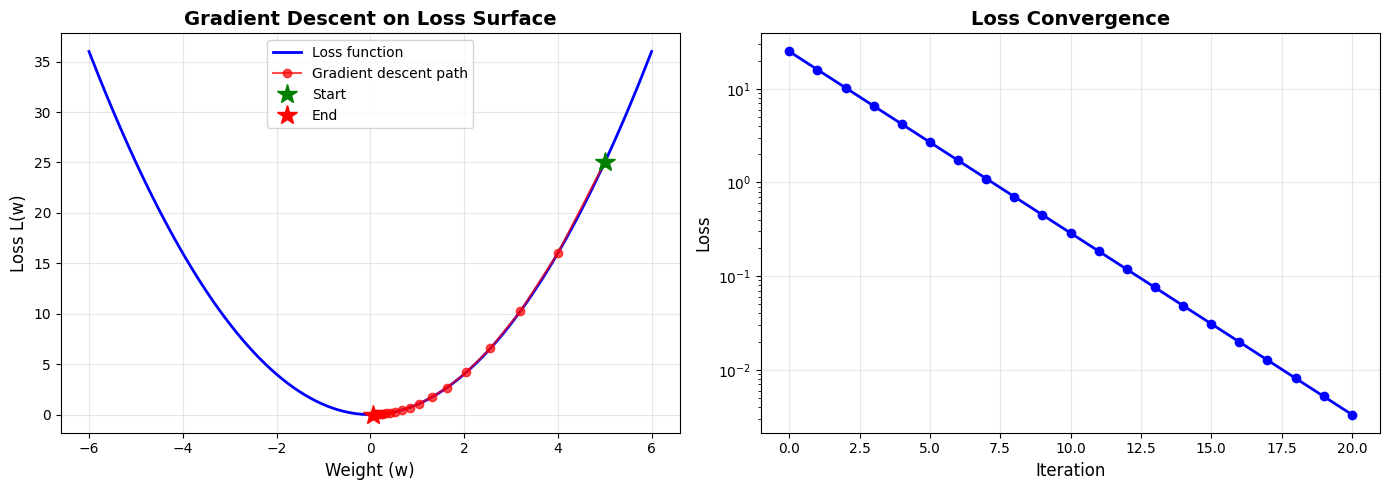


GRADIENT DESCENT RESULTS
Initial weight: 5.0000
Final weight: 0.0576
Initial loss: 25.0000
Final loss: 0.003323
Iterations: 20
Learning rate: 0.1


In [4]:
# Implement basic gradient descent

def gradient_descent_1d(loss_fn, gradient_fn, w_init, learning_rate=0.1, num_iterations=50):
    """
    Gradient descent for 1D optimization
    
    Args:
        loss_fn: Loss function L(w)
        gradient_fn: Gradient function ∇L(w)
        w_init: Initial weight
        learning_rate: Step size α
        num_iterations: Number of steps
    
    Returns:
        w_history: Weight values at each iteration
        loss_history: Loss values at each iteration
    """
    w = w_init
    w_history = [w]
    loss_history = [loss_fn(w)]
    
    for i in range(num_iterations):
        # Compute gradient
        grad = gradient_fn(w)
        
        # Update weight: w ← w - α∇L(w)
        w = w - learning_rate * grad
        
        # Store history
        w_history.append(w)
        loss_history.append(loss_fn(w))
    
    return np.array(w_history), np.array(loss_history)

# Example: Minimize f(w) = w²
def simple_loss(w):
    return w**2

def simple_gradient(w):
    return 2*w

# Run gradient descent
w_init = 5.0
learning_rate = 0.1
w_history, loss_history = gradient_descent_1d(
    simple_loss, simple_gradient, w_init, learning_rate, num_iterations=20
)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss surface with gradient descent path
w_range = np.linspace(-6, 6, 100)
loss_range = simple_loss(w_range)

axes[0].plot(w_range, loss_range, 'b-', linewidth=2, label='Loss function')
axes[0].plot(w_history, loss_history, 'ro-', markersize=6, linewidth=1.5, 
             label='Gradient descent path', alpha=0.7)
axes[0].plot(w_history[0], loss_history[0], 'g*', markersize=15, label='Start')
axes[0].plot(w_history[-1], loss_history[-1], 'r*', markersize=15, label='End')
axes[0].set_xlabel('Weight (w)', fontsize=12)
axes[0].set_ylabel('Loss L(w)', fontsize=12)
axes[0].set_title('Gradient Descent on Loss Surface', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Loss over iterations
axes[1].plot(loss_history, 'b-o', linewidth=2, markersize=6)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss Convergence', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("GRADIENT DESCENT RESULTS")
print("="*60)
print(f"Initial weight: {w_history[0]:.4f}")
print(f"Final weight: {w_history[-1]:.4f}")
print(f"Initial loss: {loss_history[0]:.4f}")
print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Iterations: {len(w_history)-1}")
print(f"Learning rate: {learning_rate}")
print("="*60)